In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import numpy as np
import json
import corner

label_fontsize = 18
tick_fontsize = 18
title_fontsize = 18

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Computer Modern"]
plt.rcParams["mathtext.fontset"] = "dejavuserif"
plt.rcParams["figure.figsize"] = (4, 3)


In [2]:
h5_path = "population_data_M1_checkSNR.h5"
with h5py.File(h5_path, "r") as h5f:
    snr_list = np.array([h5f[key]['snrs_LISA'][()] for key in h5f.keys() if 'snrs_LISA' in h5f[key].keys()])[:,0]
    m1_list = np.array([h5f[key]['m1'][()] for key in h5f.keys() if 'm1' in h5f[key].keys()])
    m2_list = np.array([h5f[key]['m2'][()] for key in h5f.keys() if 'm2' in h5f[key].keys()])
    z_list = np.array([h5f[key]['z'][()] for key in h5f.keys() if 'z' in h5f[key].keys()])
    a_list = np.array([h5f[key]['a1'][()] for key in h5f.keys() if 'a1' in h5f[key].keys()])
    Tmerger_list = np.array([h5f[key]['tmerger_yr'][()] for key in h5f.keys() if 'tmerger_yr' in h5f[key].keys()])


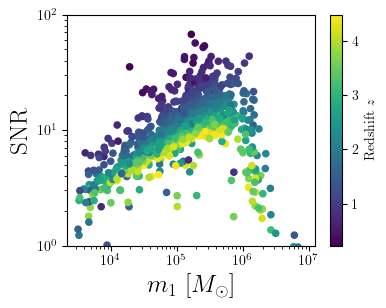

In [3]:
plt.scatter(m1_list, snr_list, c=z_list, cmap='viridis', s=20)
plt.xlabel(r"$m_1$ [$M_\odot$]", fontsize=label_fontsize)
plt.ylabel(r"SNR", fontsize=label_fontsize)
plt.ylim(1.0, 100)
plt.loglog()
plt.colorbar(label='Redshift $z$')

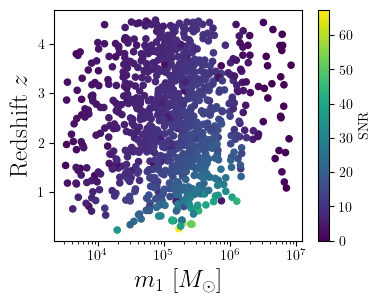

In [4]:
plt.scatter(m1_list, z_list, c=snr_list, cmap='viridis', s=20)
plt.xlabel(r"$m_1$ [$M_\odot$]", fontsize=label_fontsize)
plt.ylabel(r"Redshift $z$", fontsize=label_fontsize)
plt.semilogx()
plt.colorbar(label='SNR')

# Interpolator

In [5]:
from scipy.interpolate import LinearNDInterpolator, RBFInterpolator

# Work in log-space for m1 (spans orders of magnitude) and log(SNR)
log_m1 = np.log10(m1_list)
log_snr = np.log10(snr_list)

# Stack into (N, 2) feature matrix: [log10(m1), z]
points = np.column_stack([log_m1, z_list])

# LinearNDInterpolator: fast triangulation-based, returns NaN outside convex hull
_interp_linear = LinearNDInterpolator(points, log_snr)

# RBFInterpolator: smoother, handles boundaries better
_interp_rbf = RBFInterpolator(points, log_snr, kernel='thin_plate_spline', smoothing=0.5)

def snr_interp(m1, z, method='linear'):
    """Return interpolated SNR for given m1 [M_sun] and redshift z.

    Parameters
    ----------
    m1 : array_like
    z  : array_like
    method : 'linear' (fast) or 'rbf' (smooth)

    Returns
    -------
    snr : ndarray  (NaN outside convex hull for method='linear')
    """
    m1, z = np.atleast_1d(m1), np.atleast_1d(z)
    pts = np.column_stack([np.log10(m1), z])
    log_s = _interp_rbf(pts) if method == 'rbf' else _interp_linear(pts)
    return 10.0 ** log_s

# Sanity check: residuals on training data
snr_pred = snr_interp(m1_list, z_list)
print(f"Max relative error on training data: {np.nanmax(np.abs(snr_pred - snr_list) / snr_list):.3f}")

Max relative error on training data: 0.000


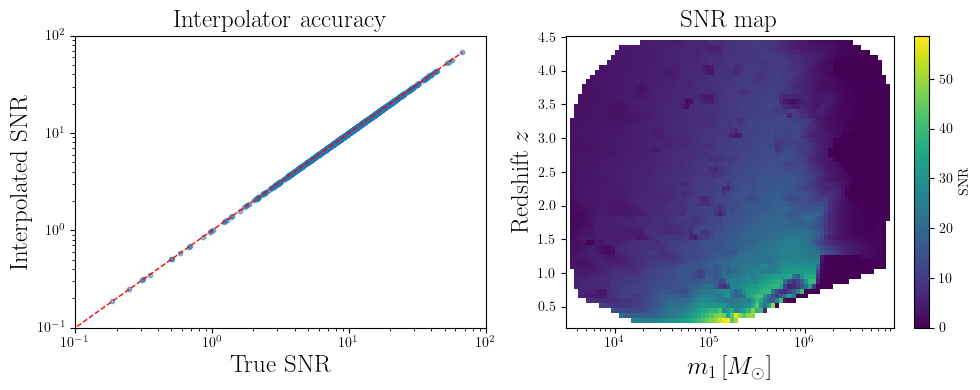

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Left: predicted vs true
ax = axes[0]
ax.scatter(snr_list, snr_pred, s=10, alpha=0.5)
lims = [snr_list.min(), snr_list.max()]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlim(1e-1, 1e2); ax.set_ylim(1e-1, 1e2)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('True SNR', fontsize=label_fontsize)
ax.set_ylabel('Interpolated SNR', fontsize=label_fontsize)
ax.set_title('Interpolator accuracy', fontsize=title_fontsize)

# Right: SNR map on a regular (m1, z) grid
ax = axes[1]
m1_grid = np.logspace(np.log10(m1_list.min()), np.log10(m1_list.max()), 80)
z_grid  = np.linspace(z_list.min(), z_list.max(), 60)
M1, Z   = np.meshgrid(m1_grid, z_grid)
SNR_map = snr_interp(M1.ravel(), Z.ravel()).reshape(M1.shape)

im = ax.pcolormesh(M1, Z, SNR_map, cmap='viridis', shading='auto')
ax.set_xscale('log')
ax.set_xlabel(r'$m_1\,[M_\odot]$', fontsize=label_fontsize)
ax.set_ylabel(r'Redshift $z$', fontsize=label_fontsize)
ax.set_title('SNR map', fontsize=title_fontsize)
fig.colorbar(im, ax=ax, label='SNR')
plt.tight_layout()
plt.show()

# Detectability

Number of sources with SNR >= 20: 98


<>:7: SyntaxWarning: invalid escape sequence '\%'
<>:7: SyntaxWarning: invalid escape sequence '\%'
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_44293/3233829190.py:7: SyntaxWarning: invalid escape sequence '\%'
  plt.axvline(20, color='red', linestyle='--', label=f'SNR=20\nDetections={len(detections)}\nPercentage={len(detections)/len(snr_list)*100:.1f}\%')


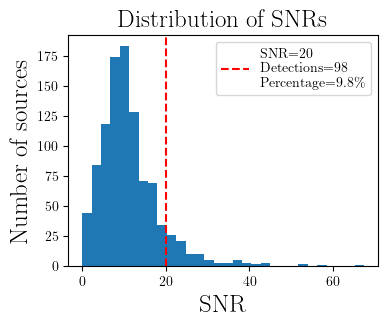

In [7]:
plt.hist(snr_list, bins=30)
mask = snr_list >= 20
detections = snr_list[mask]
print(f"Number of sources with SNR >= 20: {len(detections)}")
plt.xlabel('SNR', fontsize=label_fontsize)
plt.ylabel('Number of sources', fontsize=label_fontsize)
plt.axvline(20, color='red', linestyle='--', label=f'SNR=20\nDetections={len(detections)}\nPercentage={len(detections)/len(snr_list)*100:.1f}\%')
plt.title('Distribution of SNRs', fontsize=title_fontsize)
plt.legend()

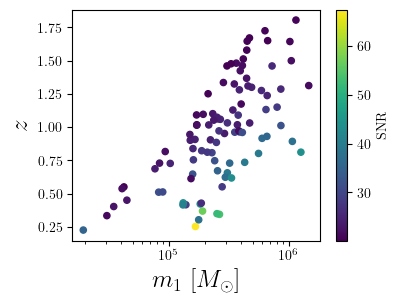

In [8]:
plt.scatter(m1_list[mask], z_list[mask], c=snr_list[mask], cmap='viridis', s=20)
plt.xlabel(r"$m_1$ [$M_\odot$]", fontsize=label_fontsize)
plt.ylabel(r"$z$", fontsize=label_fontsize)
plt.semilogx()
plt.colorbar(label='SNR')

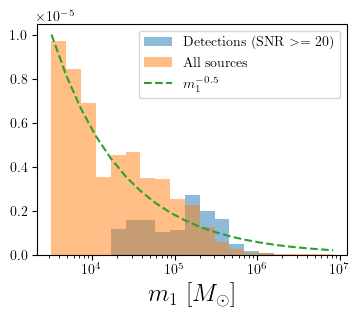

In [9]:
log_m1_bins = np.logspace(np.log10(min(m1_list)), np.log10(max(m1_list)), 20)
# selection effects
plt.figure()
plt.hist(m1_list[mask], bins=log_m1_bins, alpha=0.5, label='Detections (SNR $>=$ 20)', density=True)
plt.hist(m1_list, bins=log_m1_bins, alpha=0.5, label='All sources', density=True)
plt.plot(log_m1_bins, 1e-5 * (log_m1_bins/log_m1_bins[0])**(-0.5), label=r"$m_1^{-0.5}$", linestyle='--')
plt.xlabel(r"$m_1$ [$M_\odot$]", fontsize=label_fontsize)
plt.semilogx()
plt.legend()
plt.show()

<>:2: SyntaxWarning: invalid escape sequence '\g'
<>:2: SyntaxWarning: invalid escape sequence '\g'
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_44293/3925962500.py:2: SyntaxWarning: invalid escape sequence '\g'
  plt.hist(z_list[mask], bins=18, alpha=0.5, label='Detections (SNR $\geq$ 20)', density=True)


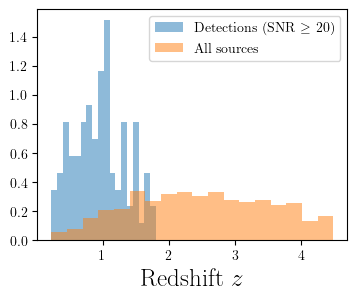

In [10]:

plt.figure()
plt.hist(z_list[mask], bins=18, alpha=0.5, label='Detections (SNR $\geq$ 20)', density=True)
plt.hist(z_list, bins=18, alpha=0.5, label='All sources', density=True)
plt.xlabel(r"Redshift $z$", fontsize=label_fontsize)
# plt.semilogx()
plt.legend()
plt.show()


In [11]:
z_list.min(), z_list.max()

(np.float64(0.2259), np.float64(4.4839))

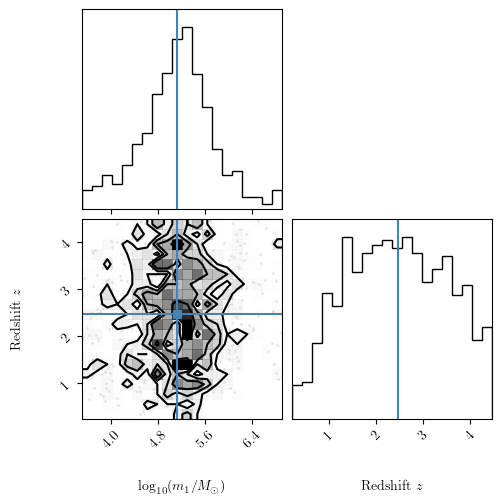

In [12]:
# population corner plot
mean_log10_m1 = np.mean(np.log10(m1_list))
mean_z = np.mean(z_list)
fig = corner.corner(np.column_stack((np.log10(m1_list), z_list)), 
                    truths=[mean_log10_m1, mean_z],
                    labels=[r"$\log_{10}(m_1 / M_\odot)$", r"Redshift $z$"])

/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_44293/3231317959.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


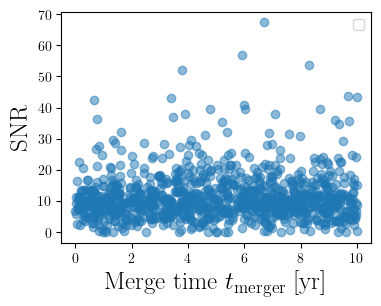

In [13]:
plt.figure()
plt.plot(Tmerger_list, snr_list, 'o', alpha=0.5)
plt.xlabel(r"Merge time $t_{\mathrm{merger}}$ [yr]", fontsize=label_fontsize)
plt.ylabel(r"SNR", fontsize=label_fontsize)
# plt.semilogx()
plt.legend()
plt.show()


# Population analysis for $m_1$ and $z$

## Population models

### $m_1$ — Mass function

$$
\ln p_\mathrm{pop}(m_1|m^*, \sigma_{\log m_1}) \propto -\frac{1}{2}\Big(\frac{\log_{10} m_1 - \log_{10} m^*}{\sigma_{\log m_1}}\Big)^2
$$

with hyper parameters given by the mean and std

### $z$ — Redshift distribution

$$
\ln p_\mathrm{pop}(m_1|z^*,\sigma_{z}) \propto -\frac{1}{2}\Big(\frac{z - z^*}{\sigma_{z}}\Big)^2
$$

with hyper parameters given by the mean and std


## Hierarchical Bayesian inference

### Per-event posteriors — delta-function approximation

We assume perfect measurement of both $m_1$ and $z$ per event:

$$
p(m_1|d_i) = \delta(m_1 - m_{1,i}), \qquad p(z|d_i) = \delta(z - z_i).
$$

This is the limit of infinitely high SNR and represents an upper bound on the population-inference precision achievable with the catalog.

### Per-event evidence

With delta-function posteriors the evidence integrals collapse to a single evaluation of the population prior at the true source values:

$$
\mathcal{Z}_i^{(m)}(\theta_m) = p_\mathrm{pop}(m_{1,i}|\theta_m), \qquad \mathcal{Z}_i^{(z)}(\theta_z) = p_\mathrm{pop}(z_i|\theta_z),
$$

so the joint log-likelihood over detected events is

$$
\ln\mathcal{L}(\{d_i\}|\theta_m,\theta_z) = \sum_{i=1}^{N_\mathrm{det}} \ln p_\mathrm{pop}(m_{1,i}|\theta_m) + \sum_{i=1}^{N_\mathrm{det}} \ln p_\mathrm{pop}(z_i|\theta_z).
$$

Explicitly, for the truncated log-normal in $m_1$ (support $[\log_{10}m_\mathrm{min},\log_{10}m_\mathrm{max}]$) and truncated Gaussian in $z$ (support $[0, z_\mathrm{max}]$):

$$
\ln p_\mathrm{pop}(m_{1,i}|\theta_m) = -\frac{(\log_{10} m_{1,i} - \mu_{\log m})^2}{2\sigma_{\log m}^2} - \ln C_m(\theta_m),
$$

$$
\ln p_\mathrm{pop}(z_i|\theta_z) = -\frac{(z_i - \mu_z)^2}{2\sigma_z^2} - \ln C_z(\theta_z),
$$

where the truncation normalisation constants are

$$
C_m(\theta_m) = \sqrt{2\pi}\,\sigma_{\log m}\,\bigl[\Phi(b_m)-\Phi(a_m)\bigr], \quad a_m = \frac{\log_{10}m_\mathrm{min} - \mu_{\log m}}{\sigma_{\log m}},\quad b_m = \frac{\log_{10}m_\mathrm{max} - \mu_{\log m}}{\sigma_{\log m}},
$$

$$
C_z(\theta_z) = \sqrt{2\pi}\,\sigma_z\,\bigl[\Phi(b_z)-\Phi(a_z)\bigr], \quad a_z = \frac{0 - \mu_z}{\sigma_z},\quad b_z = \frac{z_\mathrm{max} - \mu_z}{\sigma_z}.
$$

### Selection effects

The catalog contains only sources with $\mathrm{SNR} \geq 20$. The selection-corrected likelihood is

$$
\mathcal{L}(\{d_i\}|\theta_m,\theta_z) = \frac{1}{\xi(\theta_m,\theta_z)^{N_\mathrm{det}}} \prod_{i=1}^{N_\mathrm{det}} p_\mathrm{pop}(m_{1,i}|\theta_m)\,p_\mathrm{pop}(z_i|\theta_z),
$$

where the **selection fraction** $\xi$ is the probability that a source drawn from the population is detected:

$$
\xi(\theta_m,\theta_z) = \int_{\log_{10}m_\mathrm{min}}^{\log_{10}m_\mathrm{max}} \int_{0}^{z_\mathrm{max}} \mathbf{1}\!\left[\widehat{\mathrm{SNR}}(m_1,z)\geq 20\right] p_\mathrm{pop}(m_1|\theta_m)\, p_\mathrm{pop}(z|\theta_z)\, \mathrm{d}\log_{10}m_1\, \mathrm{d}z,
$$

with $\widehat{\mathrm{SNR}}(m_1,z)$ evaluated on a dense $(100\times 80)$ grid over the support using the linear triangulation interpolator built from the injection catalog. The integral is computed by the trapezoidal rule via two sequential matrix products, giving a smooth, noise-free $\xi$ surface.

### Full log-posterior

$$
\ln p(\theta_m,\theta_z|\{d_i\}) = \sum_{i=1}^{N_\mathrm{det}} \ln p_\mathrm{pop}(m_{1,i}|\theta_m) + \sum_{i=1}^{N_\mathrm{det}} \ln p_\mathrm{pop}(z_i|\theta_z) - N_\mathrm{det}\,\ln\xi(\theta_m,\theta_z) + \mathrm{const.}
$$

Because $\xi$ mixes $\theta_m$ and $\theta_z$ (the SNR threshold couples $m_1$ and $z$ jointly), the 4D posterior does **not** factorise in general.


In [14]:
from scipy.special import ndtr  # standard normal CDF  Φ(x)

# ── Detection threshold and catalog masks ─────────────────────────────────
SNR_thresh = 20.0
mask   = snr_list >= SNR_thresh
m1_det = m1_list[mask];  z_det = z_list[mask]
N_det  = int(mask.sum()); N_inj = len(snr_list)
log10_m1_all = np.log10(m1_list);  log10_m1_det = np.log10(m1_det)

# Population support:  log10(m1) ∈ [log10(100), log10(5×10^7)]  and  z ∈ [0, 4.5]
log10_m1_min, log10_m1_max = np.log10(1e2), np.log10(5e7)
z_min_pop, z_max_pop = 0.0, 4.5

print(f"Detected: {N_det}/{N_inj} ({100*N_det/N_inj:.1f}%)")
print(f"log10(m1) det:  mean={log10_m1_det.mean():.3f}  std={log10_m1_det.std():.3f}")
print(f"z         det:  mean={z_det.mean():.3f}  std={z_det.std():.3f}")

# Sources outside the support have p_pop = 0 and are excluded from the likelihood
m1_det_in = (log10_m1_det >= log10_m1_min) & (log10_m1_det <= log10_m1_max)
z_det_in  = (z_det  >= z_min_pop)  & (z_det  <= z_max_pop)
print(f"Detected sources inside support:  m1={m1_det_in.sum()}/{N_det},  z={z_det_in.sum()}/{N_det}")

LOG_ZERO = -1e300  # log(0) proxy — avoids NaN in log-sum-exp

# ── Hyperparameter grids ──────────────────────────────────────────────────
n_grid = 100

mu_logm_grid  = np.linspace(log10_m1_det.mean() - 1.5, log10_m1_det.mean() + 1.5, n_grid)
sig_logm_grid = np.linspace(0.1, 2.5, n_grid)

# Centre on the full-catalog mean (not the detection mean) to avoid
# pulling the grid away from the true population by selection bias
mu_z_grid  = np.linspace(max(z_min_pop + 0.02, z_list.mean() - 2*z_list.std()),
                          min(z_max_pop,         z_list.mean() + 2*z_list.std()), n_grid)
sig_z_grid = np.linspace(0.05, 3.0, n_grid)

# ── Truncation normalisation constants ────────────────────────────────────
# C_m(θ_m) = √(2π) σ_m [Φ(b_m) − Φ(a_m)],  a/b = (boundary − μ) / σ
a_m = (log10_m1_min - mu_logm_grid[:, None]) / sig_logm_grid[None, :]
b_m = (log10_m1_max - mu_logm_grid[:, None]) / sig_logm_grid[None, :]
ln_C_m = (0.5*np.log(2*np.pi) + np.log(sig_logm_grid[None, :])
          + np.log(np.clip(ndtr(b_m) - ndtr(a_m), 1e-300, None)))

a_z = (z_min_pop - mu_z_grid[:, None]) / sig_z_grid[None, :]
b_z = (z_max_pop - mu_z_grid[:, None]) / sig_z_grid[None, :]
ln_C_z = (0.5*np.log(2*np.pi) + np.log(sig_z_grid[None, :])
          + np.log(np.clip(ndtr(b_z) - ndtr(a_z), 1e-300, None)))

# ── Per-event log-evidence on detected sources ────────────────────────────
# log Z_i^(m)(θ_m) = −½[(log m_{1,i}−μ_m)/σ_m]² − ln C_m(θ_m)
# Summed over all N_det events; shape → (n_mu_m, n_sig_m)
log_Zm = (np.where(m1_det_in[None, None, :],
                   -0.5 * ((log10_m1_det[None, None, :] - mu_logm_grid[:, None, None])
                            / sig_logm_grid[None, :, None])**2,
                   LOG_ZERO).sum(axis=-1)
          - N_det * ln_C_m)

log_Zz = (np.where(z_det_in[None, None, :],
                   -0.5 * ((z_det[None, None, :] - mu_z_grid[:, None, None])
                            / sig_z_grid[None, :, None])**2,
                   LOG_ZERO).sum(axis=-1)
          - N_det * ln_C_z)

# ── Selection fraction ξ(θ) via the SNR interpolator ─────────────────────
# ξ(θ) = ∫∫ 1[SNR̂(m1,z) ≥ 20] p_pop(m1|θ_m) p_pop(z|θ_z) d(log10 m1) dz
#
# Evaluated on a dense 2D grid using the linear triangulation interpolator.
# The double integral is computed by the trapezoidal rule via two sequential
# matrix products, yielding a smooth noise-free ξ surface.

N_m_int, N_z_int = 100, 80
x_m_int = np.linspace(log10_m1_min, log10_m1_max, N_m_int)
x_z_int = np.linspace(z_min_pop,    z_max_pop,    N_z_int)
dx_m    = x_m_int[1] - x_m_int[0]
dx_z    = x_z_int[1] - x_z_int[0]

M1_int, Z_int = np.meshgrid(10**x_m_int, x_z_int, indexing='ij')
snr_grid = snr_interp(M1_int.ravel(), Z_int.ravel(), method='linear').reshape(N_m_int, N_z_int)
snr_grid = np.where(np.isfinite(snr_grid) & (snr_grid > 0), snr_grid, 0.0)
det_mask = (snr_grid >= SNR_thresh).astype(np.float64)  # shape (N_m_int, N_z_int)

print(f"\nIntegration grid: {N_m_int}×{N_z_int} = {N_m_int*N_z_int} points")
print(f"Grid detection fraction: {det_mask.mean():.3f}   (catalog: {mask.mean():.3f})")

# Unnormalized Gaussian weights at the integration nodes; shape (n_grid, n_grid, N_int)
wm_int = np.exp(-0.5 * ((x_m_int[None, None, :] - mu_logm_grid[:, None, None])
                          / sig_logm_grid[None, :, None])**2) * dx_m
wz_int = np.exp(-0.5 * ((x_z_int[None, None, :] - mu_z_grid[:, None, None])
                          / sig_z_grid[None, :, None])**2) * dx_z

# Step 1: contract over m1  →  shape (n_grid², N_z_int)
A_int = wm_int.reshape(n_grid * n_grid, N_m_int) @ det_mask
# Step 2: contract over z   →  shape (n_grid², n_grid²)
num   = A_int @ wz_int.reshape(n_grid * n_grid, N_z_int).T

# log ξ(θ) = log(numerator) − ln C_m(θ_m) − ln C_z(θ_z)
log_xi = (np.log(np.clip(num, 1e-300, None)).reshape(n_grid, n_grid, n_grid, n_grid)
          - ln_C_m[:, :, None, None]
          - ln_C_z[None, None, :, :])

# ── 4D log-posterior ──────────────────────────────────────────────────────
# ln p(θ | {d_i}) ∝ Σ_i ln p_pop(m_{1,i}|θ_m) + Σ_i ln p_pop(z_i|θ_z) − N_det ln ξ(θ)
log_post = (log_Zm[:, :, None, None]
            + log_Zz[None, None, :, :]
            - N_det * log_xi)
log_post -= log_post.max()
post = np.exp(log_post);  post /= post.sum()

# ── Marginal posteriors ───────────────────────────────────────────────────
p_m = post.sum(axis=(2, 3))   # (n_mu_m, n_sig_m)
p_z = post.sum(axis=(0, 1))   # (n_mu_z, n_sig_z)

p1_mu_m  = post.sum(axis=(1,2,3)); p1_mu_m  /= np.trapz(p1_mu_m,  mu_logm_grid)
p1_sig_m = post.sum(axis=(0,2,3)); p1_sig_m /= np.trapz(p1_sig_m, sig_logm_grid)
p1_mu_z  = post.sum(axis=(0,1,3)); p1_mu_z  /= np.trapz(p1_mu_z,  mu_z_grid)
p1_sig_z = post.sum(axis=(0,1,2)); p1_sig_z /= np.trapz(p1_sig_z, sig_z_grid)

idx = np.unravel_index(post.argmax(), post.shape)
print(f"\nMAP:  μ_logm={mu_logm_grid[idx[0]]:.3f}  σ_logm={sig_logm_grid[idx[1]]:.3f}"
      f"  μ_z={mu_z_grid[idx[2]]:.3f}  σ_z={sig_z_grid[idx[3]]:.3f}")
print(f"Inj:  μ_logm={log10_m1_all.mean():.3f}  σ_logm={log10_m1_all.std():.3f}"
      f"  μ_z={z_list.mean():.3f}  σ_z={z_list.std():.3f}")


Detected: 98/1000 (9.8%)
log10(m1) det:  mean=5.427  std=0.358
z         det:  mean=0.955  std=0.382
Detected sources inside support:  m1=98/98,  z=98/98

Integration grid: 100×80 = 8000 points
Grid detection fraction: 0.046   (catalog: 0.098)

MAP:  μ_logm=5.079  σ_logm=0.536  μ_z=2.761  σ_z=1.242
Inj:  μ_logm=5.124  σ_logm=0.625  μ_z=2.473  σ_z=1.037


/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_44293/1305237422.py:113: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p1_mu_m  = post.sum(axis=(1,2,3)); p1_mu_m  /= np.trapz(p1_mu_m,  mu_logm_grid)
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_44293/1305237422.py:114: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p1_sig_m = post.sum(axis=(0,2,3)); p1_sig_m /= np.trapz(p1_sig_m, sig_logm_grid)
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_44293/1305237422.py:115: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  p1_mu_z  = post.sum(axis=(0,1,3)); p1_mu_z  /= np.trapz(p1_mu_z,  mu_z_grid)
/var/folders/78/stbtx34d7vj939lq8bmh39wrx379gb/T/ipykernel_44293/1305237422.py:116: DeprecationW

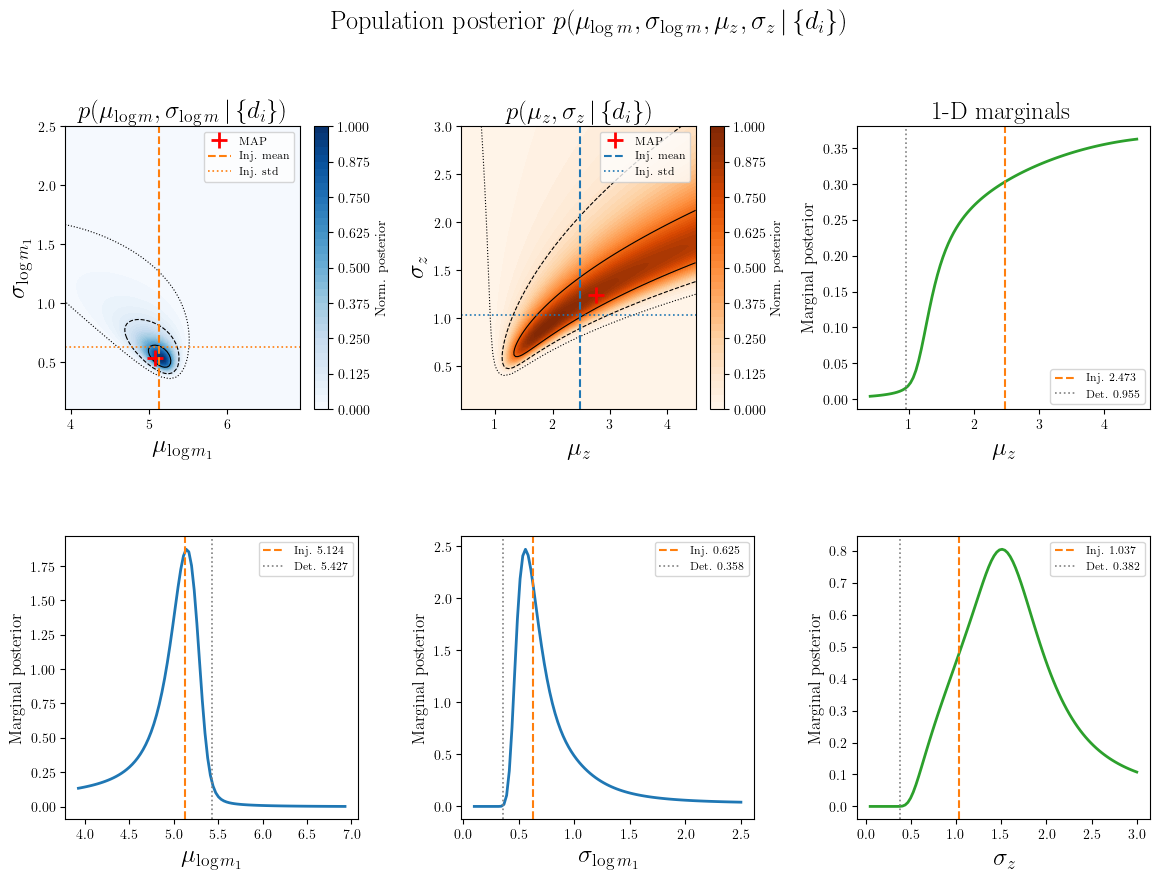

In [15]:
MU_M, SIG_M = np.meshgrid(mu_logm_grid, sig_logm_grid, indexing='ij')
MU_Z, SIG_Z = np.meshgrid(mu_z_grid,   sig_z_grid,   indexing='ij')

def sigma_contours(arr):
    """Contour levels corresponding to 1σ, 2σ, 3σ of a 2-D Gaussian."""
    return np.exp(-0.5 * np.array([9, 4, 1])) * arr.max()

fig = plt.figure(figsize=(14, 9))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ── 2D marginal: (μ_logm, σ_logm) ────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
cf = ax.contourf(MU_M, SIG_M, p_m / p_m.max(), levels=40, cmap='Blues', vmin=0, vmax=1)
ax.contour(MU_M, SIG_M, p_m, levels=sigma_contours(p_m),
           colors='k', linewidths=0.8, linestyles=[':', '--', '-'])
ax.plot(mu_logm_grid[idx[0]], sig_logm_grid[idx[1]], 'r+', ms=12, mew=2, label='MAP')
ax.axvline(log10_m1_all.mean(), color='C1', ls='--', lw=1.5, label='Inj. mean')
ax.axhline(log10_m1_all.std(),  color='C1', ls=':',  lw=1.2, label='Inj. std')
ax.set_xlabel(r'$\mu_{\log m_1}$',    fontsize=label_fontsize)
ax.set_ylabel(r'$\sigma_{\log m_1}$', fontsize=label_fontsize)
ax.set_title(r'$p(\mu_{\log m},\sigma_{\log m}\,|\,\{d_i\})$', fontsize=title_fontsize)
ax.legend(fontsize=8, loc='upper right')
plt.colorbar(cf, ax=ax, label='Norm. posterior')

# ── 2D marginal: (μ_z, σ_z) ──────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
cf = ax.contourf(MU_Z, SIG_Z, p_z / p_z.max(), levels=40, cmap='Oranges', vmin=0, vmax=1)
ax.contour(MU_Z, SIG_Z, p_z, levels=sigma_contours(p_z),
           colors='k', linewidths=0.8, linestyles=[':', '--', '-'])
ax.plot(mu_z_grid[idx[2]], sig_z_grid[idx[3]], 'r+', ms=12, mew=2, label='MAP')
ax.axvline(z_list.mean(), color='C0', ls='--', lw=1.5, label='Inj. mean')
ax.axhline(z_list.std(),  color='C0', ls=':',  lw=1.2, label='Inj. std')
ax.set_xlabel(r'$\mu_z$',  fontsize=label_fontsize)
ax.set_ylabel(r'$\sigma_z$', fontsize=label_fontsize)
ax.set_title(r'$p(\mu_z,\sigma_z\,|\,\{d_i\})$', fontsize=title_fontsize)
ax.legend(fontsize=8, loc='upper right')
plt.colorbar(cf, ax=ax, label='Norm. posterior')

# ── 1D marginals ──────────────────────────────────────────────────────────
def plot_1d(ax, grid, prob, inj_val, det_val, xlabel, color):
    ax.plot(grid, prob, lw=2, color=color)
    ax.axvline(inj_val, color='C1',  ls='--', lw=1.5, label=f'Inj. {inj_val:.3f}')
    ax.axvline(det_val, color='gray', ls=':', lw=1.2, label=f'Det. {det_val:.3f}')
    ax.set_xlabel(xlabel, fontsize=label_fontsize)
    ax.set_ylabel('Marginal posterior', fontsize=12)
    ax.legend(fontsize=8)

ax = fig.add_subplot(gs[1, 0])
plot_1d(ax, mu_logm_grid, p1_mu_m, log10_m1_all.mean(), log10_m1_det.mean(),
        r'$\mu_{\log m_1}$', 'C0')

ax = fig.add_subplot(gs[1, 1])
plot_1d(ax, sig_logm_grid, p1_sig_m, log10_m1_all.std(), log10_m1_det.std(),
        r'$\sigma_{\log m_1}$', 'C0')

ax = fig.add_subplot(gs[0, 2])
plot_1d(ax, mu_z_grid, p1_mu_z, z_list.mean(), z_det.mean(),
        r'$\mu_z$', 'C2')
ax.set_title('1-D marginals', fontsize=title_fontsize)

ax = fig.add_subplot(gs[1, 2])
plot_1d(ax, sig_z_grid, p1_sig_z, z_list.std(), z_det.std(),
        r'$\sigma_z$', 'C2')

plt.suptitle(r'Population posterior $p(\mu_{\log m},\sigma_{\log m},\mu_z,\sigma_z\,|\,\{d_i\})$',
             fontsize=title_fontsize + 1, y=1.01)
plt.show()


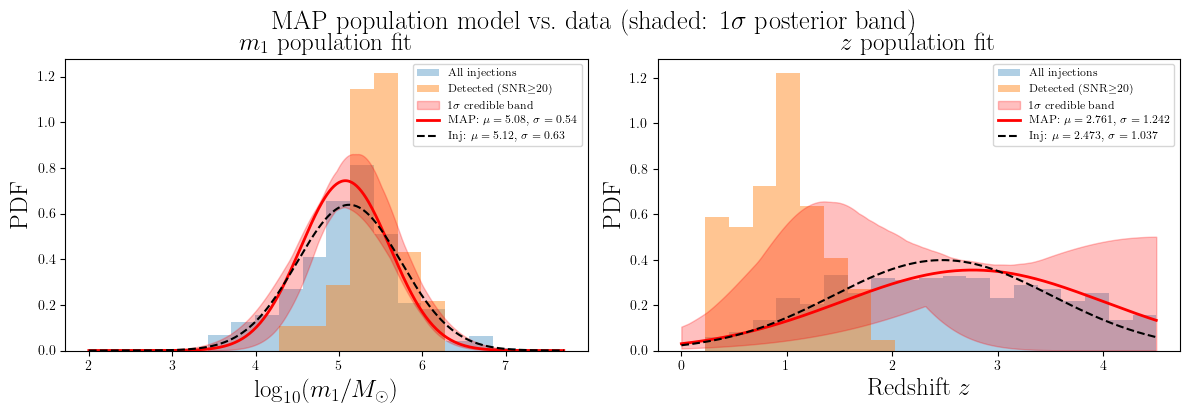

KS test — MAP model vs. data:
  log10(m1) all injections:  D=0.076  p=0.000
  log10(m1) detections:      D=0.419  p=0.000
  z         all injections:  D=0.079  p=0.000
  z         detections:      D=0.784  p=0.000

Note: the MAP is fitted to the *detected* sample, corrected for selection effects.
The MAP curve should match the detected histogram well; the offset from the
injection histogram reflects the selection bias that ξ corrects for.


In [16]:
from scipy.stats import norm as scipy_norm, ks_1samp

# ── MAP hyperparameters ───────────────────────────────────────────────────
mu_logm_map  = mu_logm_grid[idx[0]]
sig_logm_map = sig_logm_grid[idx[1]]
mu_z_map     = mu_z_grid[idx[2]]
sig_z_map    = sig_z_grid[idx[3]]

def trunc_gauss_pdf(x, mu, sig, lo, hi):
    """Truncated Gaussian PDF on [lo, hi], normalised to integrate to 1."""
    phi = scipy_norm.pdf(x, mu, sig)
    C   = scipy_norm.cdf(hi, mu, sig) - scipy_norm.cdf(lo, mu, sig)
    return np.where((x >= lo) & (x <= hi), phi / C, 0.0)

# ── Dense evaluation grids ────────────────────────────────────────────────
x_m = np.linspace(log10_m1_min, log10_m1_max, 400)
x_z = np.linspace(z_min_pop, z_max_pop, 400)

pdf_m_map = trunc_gauss_pdf(x_m, mu_logm_map, sig_logm_map, log10_m1_min, log10_m1_max)
pdf_z_map = trunc_gauss_pdf(x_z, mu_z_map,    sig_z_map,    z_min_pop,    z_max_pop)
pdf_m_inj = trunc_gauss_pdf(x_m, log10_m1_all.mean(), log10_m1_all.std(), log10_m1_min, log10_m1_max)
pdf_z_inj = trunc_gauss_pdf(x_z, z_list.mean(),       z_list.std(),       z_min_pop,    z_max_pop)

# ── 1σ credible bands from the 2D marginal posteriors ────────────────────
# Collect all (μ, σ) grid points that lie inside the 1σ contour of the 2D
# marginal posterior (i.e. where p ≥ exp(−½) × p_max).  The MAP is inside
# this region by construction, so the envelope of the corresponding PDFs is
# guaranteed to contain the MAP curve.
level_1sig_m = np.exp(-0.5) * p_m.max()
level_1sig_z = np.exp(-0.5) * p_z.max()

ii_mu_m, ii_sig_m = np.where(p_m >= level_1sig_m)
ii_mu_z, ii_sig_z = np.where(p_z >= level_1sig_z)

mu_logm_s  = mu_logm_grid[ii_mu_m];  sig_logm_s = sig_logm_grid[ii_sig_m]
mu_z_s     = mu_z_grid[ii_mu_z];     sig_z_s    = sig_z_grid[ii_sig_z]

# Vectorised PDF evaluation over all in-contour (μ, σ) pairs
# Shapes: (n_in_contour, len(x))
Cm = (scipy_norm.cdf(log10_m1_max, mu_logm_s[:, None], sig_logm_s[:, None])
      - scipy_norm.cdf(log10_m1_min, mu_logm_s[:, None], sig_logm_s[:, None]))
pdf_m_band = scipy_norm.pdf(x_m[None, :], mu_logm_s[:, None], sig_logm_s[:, None]) / Cm

Cz = (scipy_norm.cdf(z_max_pop, mu_z_s[:, None], sig_z_s[:, None])
      - scipy_norm.cdf(z_min_pop, mu_z_s[:, None], sig_z_s[:, None]))
pdf_z_band = scipy_norm.pdf(x_z[None, :], mu_z_s[:, None], sig_z_s[:, None]) / Cz

pdf_m_lo, pdf_m_hi = pdf_m_band.min(axis=0), pdf_m_band.max(axis=0)
pdf_z_lo, pdf_z_hi = pdf_z_band.min(axis=0), pdf_z_band.max(axis=0)

# ── Figure: MAP model + 1σ band vs. data ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# log10(m1) panel
ax = axes[0]
log_m1_bins = np.linspace(log10_m1_min, log10_m1_max, 21)
ax.hist(log10_m1_all, bins=log_m1_bins, density=True, alpha=0.35,
        color='C0', label='All injections')
ax.hist(log10_m1_det, bins=log_m1_bins, density=True, alpha=0.45,
        color='C1', label=rf'Detected (SNR$\geq${SNR_thresh:.0f})')
ax.fill_between(x_m, pdf_m_lo, pdf_m_hi, color='r', alpha=0.25, label=r'$1\sigma$ credible band')
ax.plot(x_m, pdf_m_map, 'r-', lw=2,
        label=rf'MAP: $\mu={mu_logm_map:.2f}$, $\sigma={sig_logm_map:.2f}$')
ax.plot(x_m, pdf_m_inj, 'k--', lw=1.5,
        label=rf'Inj: $\mu={log10_m1_all.mean():.2f}$, $\sigma={log10_m1_all.std():.2f}$')
ax.set_xlabel(r'$\log_{10}(m_1/M_\odot)$', fontsize=label_fontsize)
ax.set_ylabel('PDF', fontsize=label_fontsize)
ax.set_title(r'$m_1$ population fit', fontsize=title_fontsize)
ax.legend(fontsize=8)

# Redshift panel
ax = axes[1]
z_bins = np.linspace(z_min_pop, z_max_pop, 21)
ax.hist(z_list, bins=z_bins, density=True, alpha=0.35,
        color='C0', label='All injections')
ax.hist(z_det,  bins=z_bins, density=True, alpha=0.45,
        color='C1', label=rf'Detected (SNR$\geq${SNR_thresh:.0f})')
ax.fill_between(x_z, pdf_z_lo, pdf_z_hi, color='r', alpha=0.25, label=r'$1\sigma$ credible band')
ax.plot(x_z, pdf_z_map, 'r-', lw=2,
        label=rf'MAP: $\mu={mu_z_map:.3f}$, $\sigma={sig_z_map:.3f}$')
ax.plot(x_z, pdf_z_inj, 'k--', lw=1.5,
        label=rf'Inj: $\mu={z_list.mean():.3f}$, $\sigma={z_list.std():.3f}$')
ax.set_xlabel(r'Redshift $z$', fontsize=label_fontsize)
ax.set_ylabel('PDF', fontsize=label_fontsize)
ax.set_title(r'$z$ population fit', fontsize=title_fontsize)
ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle(r'MAP population model vs.\ data (shaded: $1\sigma$ posterior band)',
             fontsize=title_fontsize + 1, y=1.02)
plt.show()

# ── KS test: MAP model vs. detections ────────────────────────────────────
m1_in_support = (log10_m1_all >= log10_m1_min) & (log10_m1_all <= log10_m1_max)
z_in_support  = (z_list >= z_min_pop) & (z_list <= z_max_pop)

def trunc_cdf_m(x):
    return (scipy_norm.cdf(x, mu_logm_map, sig_logm_map)
            - scipy_norm.cdf(log10_m1_min, mu_logm_map, sig_logm_map)) / \
           (scipy_norm.cdf(log10_m1_max, mu_logm_map, sig_logm_map)
            - scipy_norm.cdf(log10_m1_min, mu_logm_map, sig_logm_map))

def trunc_cdf_z(x):
    return (scipy_norm.cdf(x, mu_z_map, sig_z_map)
            - scipy_norm.cdf(z_min_pop, mu_z_map, sig_z_map)) / \
           (scipy_norm.cdf(z_max_pop, mu_z_map, sig_z_map)
            - scipy_norm.cdf(z_min_pop, mu_z_map, sig_z_map))

ks_m_all = ks_1samp(log10_m1_all[m1_in_support], trunc_cdf_m)
ks_m_det = ks_1samp(log10_m1_det[m1_det_in],     trunc_cdf_m)
ks_z_all = ks_1samp(z_list[z_in_support],         trunc_cdf_z)
ks_z_det = ks_1samp(z_det[z_det_in],              trunc_cdf_z)

print("KS test — MAP model vs. data:")
print(f"  log10(m1) all injections:  D={ks_m_all.statistic:.3f}  p={ks_m_all.pvalue:.3f}")
print(f"  log10(m1) detections:      D={ks_m_det.statistic:.3f}  p={ks_m_det.pvalue:.3f}")
print(f"  z         all injections:  D={ks_z_all.statistic:.3f}  p={ks_z_all.pvalue:.3f}")
print(f"  z         detections:      D={ks_z_det.statistic:.3f}  p={ks_z_det.pvalue:.3f}")
print("\nNote: the MAP is fitted to the *detected* sample, corrected for selection effects.")
print("The MAP curve should match the detected histogram well; the offset from the")
print("injection histogram reflects the selection bias that ξ corrects for.")
